<a href="https://colab.research.google.com/github/XiaoyangLYY/portfolio-optimization/blob/main/optimization_lxy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
# ============================================================
# FULL PIPELINE — S&P 500 股票组合选股
# Choice 2: 30支个股，周频数据，月度调仓，rolling window = 1年
# ============================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import requests
from io import StringIO
import matplotlib.pyplot as plt

# ============================================================
# STEP 1: 获取 S&P 500 成分股 + 行业信息
# ============================================================

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
sp500 = pd.read_html(StringIO(response.text))[0]
sp500 = sp500[['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry']].copy()
sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-', regex=False)

print(f"S&P 500 成分股数量: {len(sp500)}")
print(f"行业分布:\n{sp500['GICS Sector'].value_counts().to_string()}")

# ============================================================
# STEP 2: 下载价格数据
# ============================================================

tickers = sp500['Symbol'].tolist()

raw = yf.download(
    tickers,
    start="2016-01-01",
    end="2026-01-01",
    interval="1wk",
    auto_adjust=True,
    group_by='ticker',
    progress=True
)

# 适配新版 yfinance: columns.names = ['Price', 'Ticker']
print(f"\nyfinance MultiIndex level names: {raw.columns.names}")

close  = raw.xs('Close',  axis=1, level='Price').copy()
volume = raw.xs('Volume', axis=1, level='Price').copy()



[                       0%                       ]  2 of 503 completed

S&P 500 成分股数量: 503
行业分布:
GICS Sector
Industrials               79
Financials                76
Information Technology    71
Health Care               60
Consumer Discretionary    48
Consumer Staples          36
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22


[*********************100%***********************]  503 of 503 completed
[*********************101%***********************]  508 of 503 completed


yfinance MultiIndex level names: ['Ticker', 'Price']



清洗后 close shape:  (522, 503)
清洗后 volume shape: (522, 503)
时间范围: 2016-01-01 → 2025-12-26

过滤稀疏ticker后 prices shape: (522, 468)
（删除了 35 个数据不足的ticker）

returns shape: (521, 468)
可用ticker数: 468

有效股票数: 468
覆盖行业数: 11

各行业分配名额 (合计=30):
GICS Sector
Information Technology    3
Consumer Discretionary    3
Financials                3
Communication Services    3
Health Care               3
Industrials               3
Consumer Staples          3
Energy                    3
Utilities                 2
Materials                 2
Real Estate               2

  最终 Portfolio（30 支股票）
Symbol                Security            GICS Sector  proxy_mktcap
  TSLA             Tesla, Inc. Consumer Discretionary  7.167980e+10
  AAPL              Apple Inc. Information Technology  4.439207e+10
  AMZN                  Amazon Consumer Discretionary  3.656242e+10
  MSFT               Microsoft Information Technology  2.886689e+10
  NVDA                  Nvidia Information Technology  2.398394e+10
  META          M

FileNotFoundError: [Errno 2] No such file or directory: 'results/portfolio_overview.png'

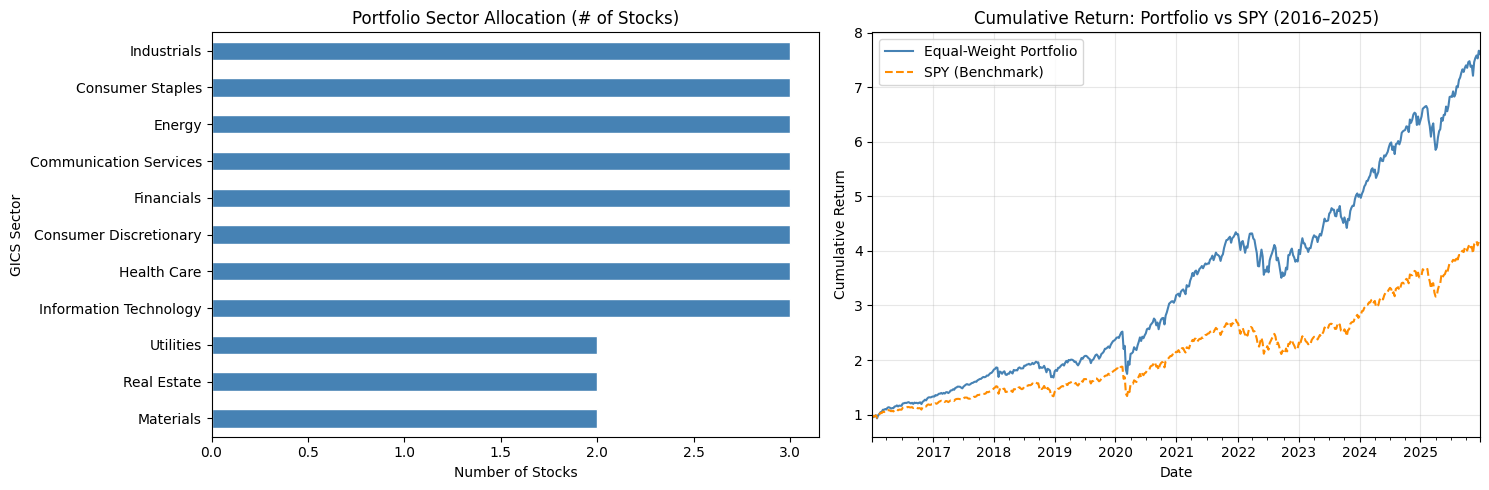

In [36]:
# ============================================================
# STEP 3: 清洗 — 删除非交易周空行
# ============================================================

# 删除全部或绝大多数股票都是NaN的行（非交易周、节假日）
row_coverage = close.notna().mean(axis=1)        # 每行有数据的股票比例
close  = close[row_coverage > 0.5].copy()        # 超过50%股票有数据才保留
volume = volume[volume.notna().mean(axis=1) > 0.5].copy()

# 对齐 index
common_index = close.index.intersection(volume.index)
close  = close.loc[common_index]
volume = volume.loc[common_index]

print(f"\n清洗后 close shape:  {close.shape}")
print(f"清洗后 volume shape: {volume.shape}")
print(f"时间范围: {close.index[0].date()} → {close.index[-1].date()}")

# ============================================================
# STEP 4: 过滤稀疏 ticker（要求至少85%周有数据）
# ============================================================

thresh = int(len(close) * 0.85)
prices = close.dropna(axis=1, thresh=thresh).copy()

print(f"\n过滤稀疏ticker后 prices shape: {prices.shape}")
print(f"（删除了 {close.shape[1] - prices.shape[1]} 个数据不足的ticker）")

# ============================================================
# STEP 5: 生成周收益率
# ============================================================

returns = prices.pct_change()
returns = returns.iloc[1:]                        # 删除第一行NaN
returns = returns.dropna(axis=1, how='any')       # 删除任意含NaN的列（保证矩阵完整）

print(f"\nreturns shape: {returns.shape}")
print(f"可用ticker数: {returns.shape[1]}")

# ============================================================
# STEP 6: 计算代理市值，每行业选代表性股票
# 均匀分配：11行业，8个行业3支 + 3个行业2支 = 30支
# 代理市值 = median(Close × Volume)，只用 returns 里存在的ticker
# ============================================================

# 只保留 returns 中有完整数据的 ticker
valid_tickers = returns.columns.tolist()
close_v  = close[valid_tickers]
volume_v = volume[valid_tickers]

# 计算代理市值
turnover     = close_v * volume_v
proxy_mktcap = turnover.median(axis=0).rename("proxy_mktcap")

# 合并行业信息
stock_info = (sp500[sp500['Symbol'].isin(valid_tickers)]
              .set_index('Symbol')
              .copy())
stock_info['proxy_mktcap'] = proxy_mktcap
stock_info = stock_info.dropna(subset=['proxy_mktcap'])

print(f"\n有效股票数: {len(stock_info)}")
print(f"覆盖行业数: {stock_info['GICS Sector'].nunique()}")

# 分配名额：按行业总代理市值排序，前8大行业各3支，后3个行业各2支
PORTFOLIO_SIZE = 30
n_sectors      = stock_info['GICS Sector'].nunique()
base           = PORTFOLIO_SIZE // n_sectors          # = 2
extra          = PORTFOLIO_SIZE % n_sectors           # = 8

sector_total = (stock_info.groupby('GICS Sector')['proxy_mktcap']
                .sum()
                .sort_values(ascending=False))
sector_quota = pd.Series(base, index=sector_total.index)
sector_quota.iloc[:extra] += 1

print(f"\n各行业分配名额 (合计={sector_quota.sum()}):")
print(sector_quota.sort_values(ascending=False).to_string())

# 每行业选 proxy_mktcap 最大的 N 支
selected = []
for sector, n in sector_quota.items():
    top_n = (stock_info[stock_info['GICS Sector'] == sector]
             .nlargest(n, 'proxy_mktcap'))
    selected.append(top_n)

portfolio = (pd.concat(selected)
               .sort_values('proxy_mktcap', ascending=False)
               .reset_index())

print(f"\n{'='*55}")
print(f"  最终 Portfolio（{len(portfolio)} 支股票）")
print(f"{'='*55}")
print(portfolio[['Symbol', 'Security', 'GICS Sector', 'proxy_mktcap']]
      .to_string(index=False))

# ============================================================
# STEP 7: 提取 Portfolio 的价格和收益率
# ============================================================

ptickers        = portfolio['Symbol'].tolist()
portfolio_prices  = prices[ptickers].copy()
portfolio_returns = returns[ptickers].copy()

print(f"\nportfolio_prices  shape: {portfolio_prices.shape}")
print(f"portfolio_returns shape: {portfolio_returns.shape}")

# ============================================================
# STEP 8: 可视化（修复SPY对齐问题）
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 左图：各行业名额
sector_quota.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Portfolio Sector Allocation (# of Stocks)', fontsize=12)
axes[0].set_xlabel('Number of Stocks')

# 右图：等权累计收益率 vs SPY
eq_returns = portfolio_returns.mean(axis=1)
cum_eq = (1 + eq_returns).cumprod()

# 下载SPY，明确去掉timezone
spy_raw = yf.download('SPY', start="2016-01-01", end="2026-01-01",
                      interval='1wk', auto_adjust=True, progress=False)
spy_close = spy_raw['Close'].squeeze()
spy_close.index = pd.to_datetime(spy_close.index).tz_localize(None)
spy_ret = spy_close.pct_change().dropna()

# 用 reindex 对齐到 portfolio_returns 的 index
spy_ret_aligned = spy_ret.reindex(portfolio_returns.index)
cum_spy = (1 + spy_ret_aligned).cumprod()

cum_eq.plot(ax=axes[1], label='Equal-Weight Portfolio', color='steelblue')
cum_spy.plot(ax=axes[1], label='SPY (Benchmark)', color='darkorange', linestyle='--')
axes[1].set_title('Cumulative Return: Portfolio vs SPY (2016–2025)', fontsize=12)
axes[1].set_ylabel('Cumulative Return')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/portfolio_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存")

# ============================================================
# STEP 9: 保存关键变量（供后续 clustering / 优化使用）
# ============================================================

print(f"\n{'='*40}")
print("  后续可直接使用的变量：")
print(f"{'='*40}")
print("  portfolio        → 30支股票信息 DataFrame")
print("  ptickers         → 30支股票 ticker 列表")
print("  portfolio_prices → 周收盘价  (weeks × 30)")
print("  portfolio_returns→ 周收益率  (weeks × 30)")
print("  prices           → 全市场周收盘价")
print("  returns          → 全市场周收益率")